<a href="https://colab.research.google.com/github/krithikasanga/capestone_projects_ml/blob/main/regmet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv('/content/placement (1).csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [ ]:
x=df.iloc[:,0:1]
x


,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [ ]:
y=df.iloc[:,-1]
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


Text(0, 0.5, 'Package(in lpa)')

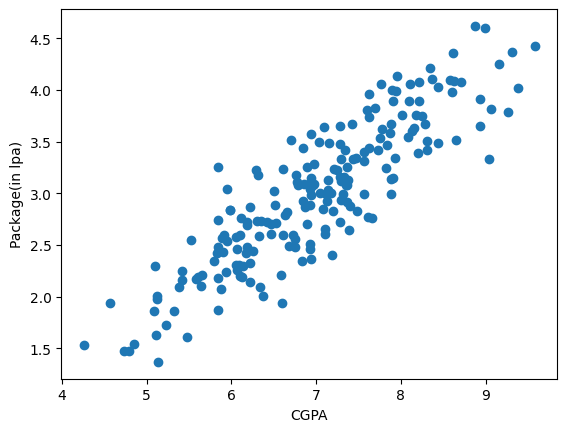

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.linear_model import LinearRegression

l1=LinearRegression()


In [ ]:
l1.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=l1.predict(x_test)

Text(0, 0.5, 'Package(in lpa)')

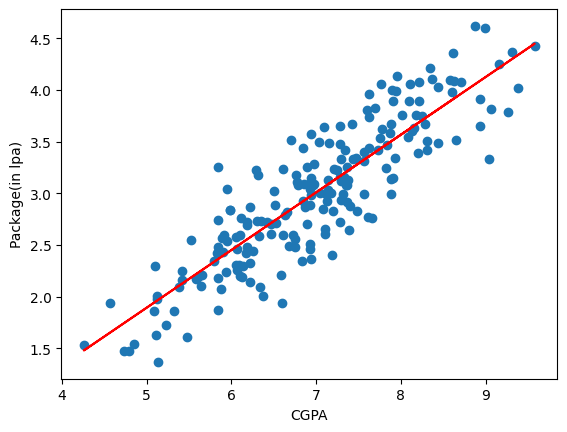

In [ ]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,l1.predict(x_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score



In [ ]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)#mae will give u the output in same units #mot used as loss fucntion since mod is non differentiable at 0

0.2884710931878175


In [ ]:
mse=mean_squared_error(y_test,y_pred)
print(mse)#it wont give u the output in exact units since its squared

0.12129235313495527


In [ ]:
rmse=np.sqrt(mse)
print(rmse)#gives u exact units

0.34827051717731616


In [ ]:
#r2 score
r2=r2_score(y_test,y_pred)
print(r2)#78 percent cgpa is explainable to lpa

0.780730147510384


$$
R_{adj}^{2} = 1 - \frac{(1 - R^{2})(n - 1)}{n - k - 1}
$$

In [ ]:
n=y_test.shape[0]
n

40

In [ ]:
k=1#number of columns

In [ ]:
ar2=1-((1-r2)*(n-1)/(n-k-1))
print(ar2)

0.7749598882343415


how r2 and ar2 works

First 5 rows of dataset:
   cgpa  random_feature  package
0  6.89        0.078943     3.26
1  5.12        0.315763     1.98
2  7.82        0.296884     3.25
3  7.42        0.110346     3.67
4  6.94        0.157076     3.57


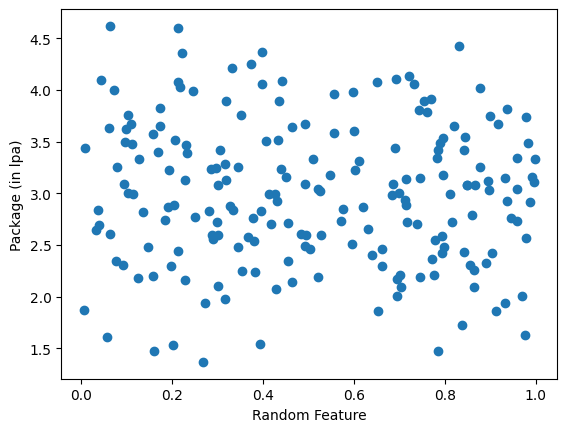

R2 Score: 0.7936288797627153
Adjusted R2 Score: 0.7824736840742135


In [ ]:
# Copy the original dataset
new_df1 = df.copy()

# Create a completely random feature (this has no real relationship with package)
new_df1['random_feature'] = np.random.random(200)

# Select only the required columns
new_df1 = new_df1[['cgpa','random_feature','package']]

# Display first 5 rows
print("First 5 rows of dataset:")
print(new_df1.head())


# Scatter plot to see relationship between random_feature and package
# Since this feature is random, points will look scattered
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('Random Feature')
plt.ylabel('Package (in lpa)')
plt.show()


# Separate features (X) and target variable (y)
X = new_df1.iloc[:,0:2]   # cgpa and random_feature
y = new_df1.iloc[:,-1]    # package


# Split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


# Create Linear Regression model
lr = LinearRegression()

# Train the model
lr.fit(X_train,y_train)


# Predict package values for test data
y_pred = lr.predict(X_test)


# Calculate R2 score (model performance)
r2 = r2_score(y_test,y_pred)
print("R2 Score:", r2)


# Calculate Adjusted R2 score
# n = number of observations in test set (40)
# k = number of features (2: cgpa and random_feature)
adj_r2 = 1 - ((1-r2)*(40-1)/(40-1-2))

print("Adjusted R2 Score:", adj_r2)

> **Observation**
>
> Even though the added feature is irrelevant, the **R² score increased**.  
> Earlier the **R² score was 0.780730147510384**, but after adding the random feature it increased to **0.7936288797627153**.
>
> This is misleading because the new feature does not actually improve the model.  
>
> **Adjusted R² solves this problem.** Since the added feature is random and not useful, Adjusted R² penalizes the model complexity and reduces the score to **0.7824736840742135**.
>
> **Hence, Adjusted R² is more reliable when multiple features are present because it accounts for unnecessary features.**

Sample rows from dataset:
     cgpa    iq  package
131  6.37  2.91     2.01
77   8.99  4.80     4.60
82   5.58  2.27     2.17
48   8.63  5.09     4.09
165  8.21  2.98     4.08


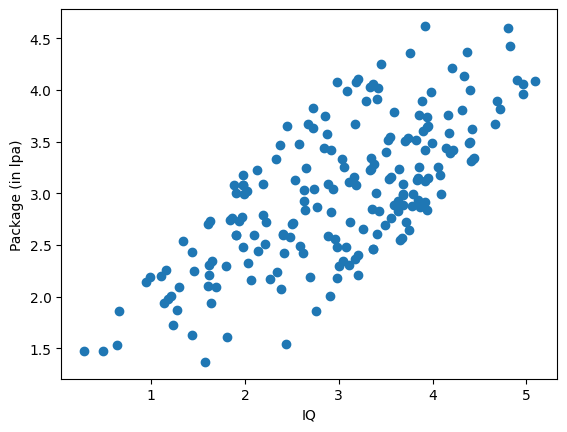

R2 Score: 0.8337853674867742
Adjusted R2 Score: 0.8248007927563296


In [ ]:
# Copy the original dataset again
new_df2 = df.copy()

# Create a new feature 'iq'
# It is correlated with package (package + small random noise)
# This means iq has some useful information
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

# Select required columns
new_df2 = new_df2[['cgpa','iq','package']]

# Display some random rows
print("Sample rows from dataset:")
print(new_df2.sample(5))


# Scatter plot to see relationship between iq and package
# Since iq is correlated with package, points will follow a pattern
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('IQ')
plt.ylabel('Package (in lpa)')
plt.show()


# Separate features and target
X = new_df2.iloc[:,0:2]   # cgpa and iq
y = new_df2.iloc[:,-1]    # package


# Split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


# Create Linear Regression model
lr = LinearRegression()

# Train the model
lr.fit(X_train,y_train)


# Predict package values
y_pred = lr.predict(X_test)


# Calculate R2 score
r2 = r2_score(y_test,y_pred)
print("R2 Score:", r2)


# Calculate Adjusted R2 score
# n = number of observations in test set (40)
# k = number of features (2: cgpa and iq)
adj_r2 = 1 - ((1-r2)*(40-1)/(40-1-2))

print("Adjusted R2 Score:", adj_r2)

> **Observation**
>
> When a relevant feature such as **IQ** is added, the **R² score increases** because the new feature has a meaningful relationship with the target variable (**package**).
>
> This indicates that the model is able to explain more variance in the data due to the additional useful information provided by the new feature.
>
> **Adjusted R² also increases in this case.** Unlike the previous example with a random feature, Adjusted R² does not penalize the model because the added feature genuinely improves the model’s predictive ability.
>
> **Hence, when a relevant feature is added, both R² and Adjusted R² increase, confirming that the new feature contributes useful information to the model.**